# Demonstration of Robust Workflow with start_time > 0 feature

This notebook demonstrates the use of the RobustWorkflow class from the quends package when a start_time > 0 is passed in. 
This is a common situation when data comes from a gyrokinetic simulation that has been restarted from a different configuration and the data from this previous run should be ignored.

## Import Required Libraries and Helper Functions

In [1]:
# Import required libraries
import numpy as np
import quends as qnds
import pprint
import pandas as pd
from pathlib import Path

# Custom class to specify formatting of floats (and tuples of floats) in pprint 
# and limit the number of significant digits in results dictionaries printed to screen
class FloatFormatter(pprint.PrettyPrinter):
    def _format(self, object, stream, indent, allowance, context, level):
        if isinstance(object, tuple):
            stream.write('(')
            for i, item in enumerate(object):
                if isinstance(item, float):
                    stream.write(format(item, '.4g'))
                else:
                    super()._format(item, stream, indent, allowance, context, level)
                if i < len(object) - 1:
                    stream.write(', ')
            stream.write(')')
        elif isinstance(object, float):
            stream.write(format(object, '.4g'))
        else:
            super()._format(object, stream, indent, allowance, context, level)

# use as 'formatter.pprint(object)'
formatter = FloatFormatter(indent=0)


def sanitize(obj):
    """Convert NumPy scalar values to native Python values recursively."""
    if isinstance(obj, dict):
        return {key: sanitize(value) for key, value in obj.items()}
    if isinstance(obj, tuple):
        return tuple(sanitize(value) for value in obj)
    if isinstance(obj, list):
        return [sanitize(value) for value in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    return obj


def flatten_stats_dataframe(df_stats: pd.DataFrame) -> pd.DataFrame:
    """Flatten nested workflow stats into scalar CSV-friendly columns."""

    def flatten_value(prefix, value, out):
        value = sanitize(value)
        if isinstance(value, dict):
            for key, nested_value in value.items():
                flatten_value(f"{prefix}.{key}", nested_value, out)
        elif isinstance(value, (list, tuple)):
            labels = ("lower", "upper") if len(value) == 2 else range(len(value))
            for label, nested_value in zip(labels, value):
                flatten_value(f"{prefix}.{label}", nested_value, out)
        else:
            out[prefix] = value

    rows = []
    for _, row in df_stats.iterrows():
        flat_row = {}
        for column_name, value in row.items():
            flatten_value(column_name, value, flat_row)
        rows.append(flat_row)
    return pd.DataFrame(rows)


def save_stats_to_csv(df_stats: pd.DataFrame, file_path_str: str = "output.csv") -> Path:
    """Save notebook statistics to the start_time_demo regression output directory."""
    repo_root = Path.cwd()
    while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
        repo_root = repo_root.parent
    file_path = repo_root / "tests" / "start_time_demo" / "output" / file_path_str
    file_path.parent.mkdir(parents=True, exist_ok=True)
    df_flat = flatten_stats_dataframe(df_stats)
    df_flat.to_csv(file_path, index=False)
    print(f"Data saved to {file_path.resolve()}")
    return file_path


## Demonstration on synthetic data
For these demonstrations, we set the verbosity to 2 so you can see plots of intermediate steps.

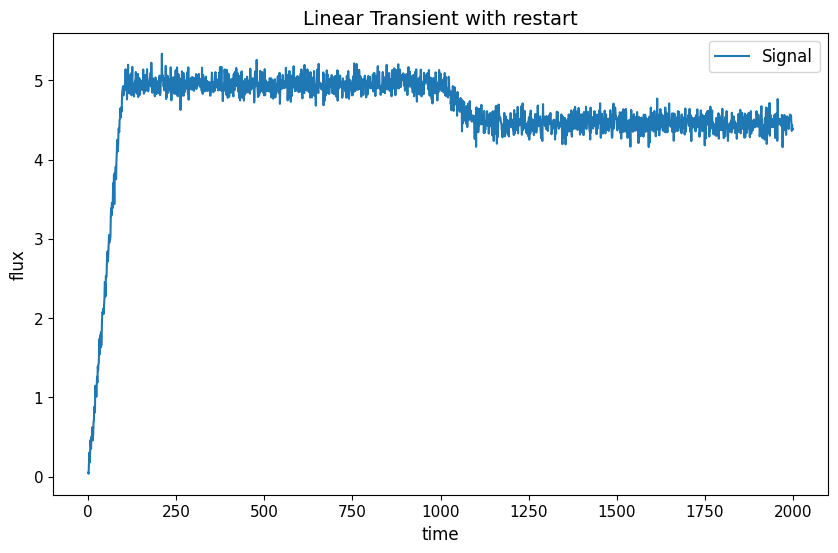

In [2]:
# Create time trace with linear transient up to flat signal with noise
np.random.seed(42)

# set up arrays for time and signal
arr_time = np.linspace(start=0,stop=2000,num=2001)
arr_signal = np.zeros_like(arr_time)

n_pts = arr_signal.shape[0]

for i_arr in range(100):
    arr_signal[i_arr] = 0.05*arr_time[i_arr]
for i_arr in range(100,1000):
    arr_signal[i_arr] = arr_signal[99]
for i_arr in range(1000,1100):
    arr_signal[i_arr] = arr_signal[999] -0.005*(arr_time[i_arr]-arr_time[999])
for i_arr in range(1100,n_pts):
    arr_signal[i_arr] = arr_signal[1099]

# add some noise
arr_signal += np.random.normal(loc=0.0, scale=0.1, size=arr_signal.shape)

my_label = "Linear Transient with restart"
# build data_stream
df_flat = pd.DataFrame({"time":arr_time,"flux":arr_signal})

ds_flat = qnds.DataStream(df_flat)

# Set up the workflow with high verbosity to see intermediate steps
my_wrkflw = qnds.RobustWorkflow(operate_safe=False, verbosity=2)

col = "flux" # variable to look at

# Plot raw signal
my_wrkflw.plot_signal_basic_stats(ds_flat,col,label=my_label)

Original size of data stream: 2001 points.
After enforcing start time there are 2001 points left.


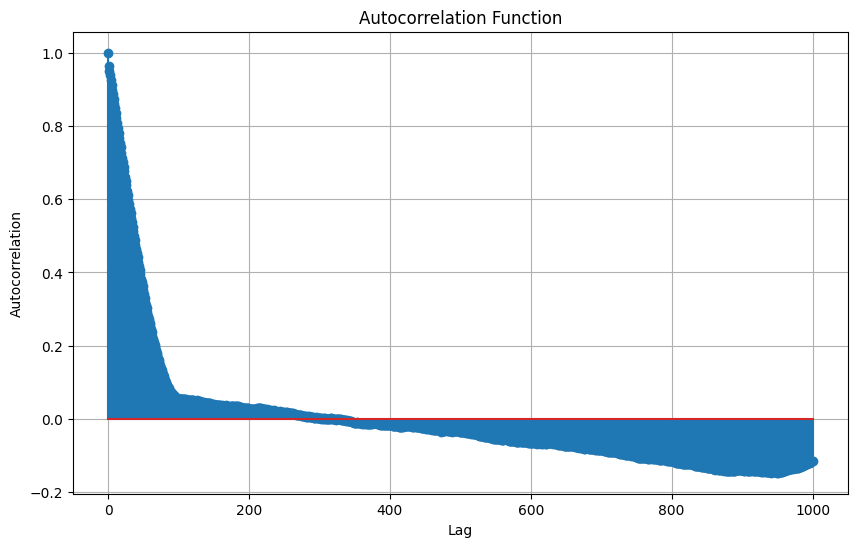

stats decorrelation time 93.23 gives smoothing window of 559 points.


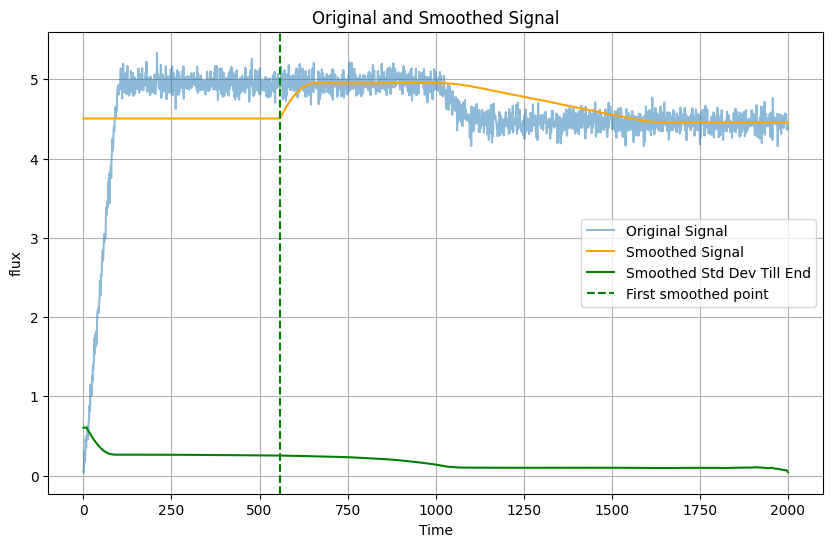

Getting start of SSS based on smoothed signal:
Index where criterion is met: 1234
Rolling window: 559
time where criterion is met: 1234.00
time at start of SSS (adjusted for rolling window): 954.00


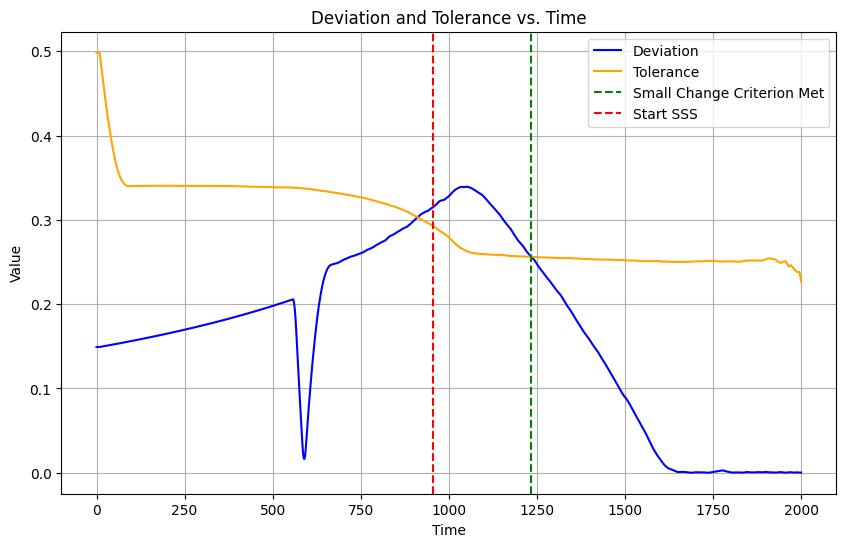

Data saved to /Users/bjdebus/Research/FESFrontiers/Repos/quends/tests/start_time_demo/output/flat_signal_stats_without_time_of_restart.csv


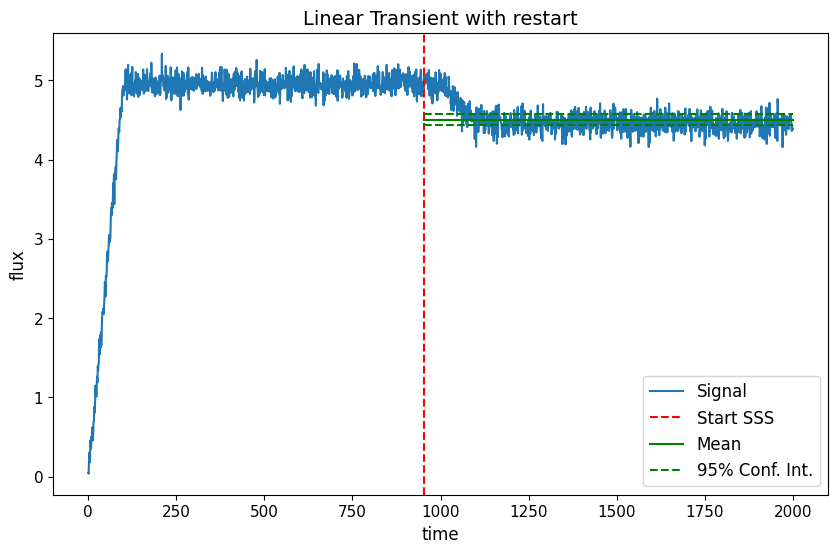

In [3]:
# get statistics without specifying the time of restart
my_stats = my_wrkflw.process_data_steam(ds_flat,col)
df_stats = pd.DataFrame([my_stats])
save_stats_to_csv(df_stats, "flat_signal_stats_without_time_of_restart.csv")

# Plot trace with mean and start of steady state
if not my_stats[col]["metadata"]["mitigation"] == "Drop":
    my_wrkflw.plot_signal_basic_stats(ds_flat,col,stats=my_stats,label=my_label)


Because the change in levels between the two segments is small, the full signal is considered stationary. Because of the small level of white noise, and the smooth transition, this signal has a large decorrelation length. Even though the area with constant smoothed mean is properly detected, the large decorrelation length puts the start of SSS way back in the old regime. creating inaccurate statistics. 

Next we help the analysis by providing the time of restart of the configuration

Original size of data stream: 2001 points.
After enforcing start time there are 1000 points left.


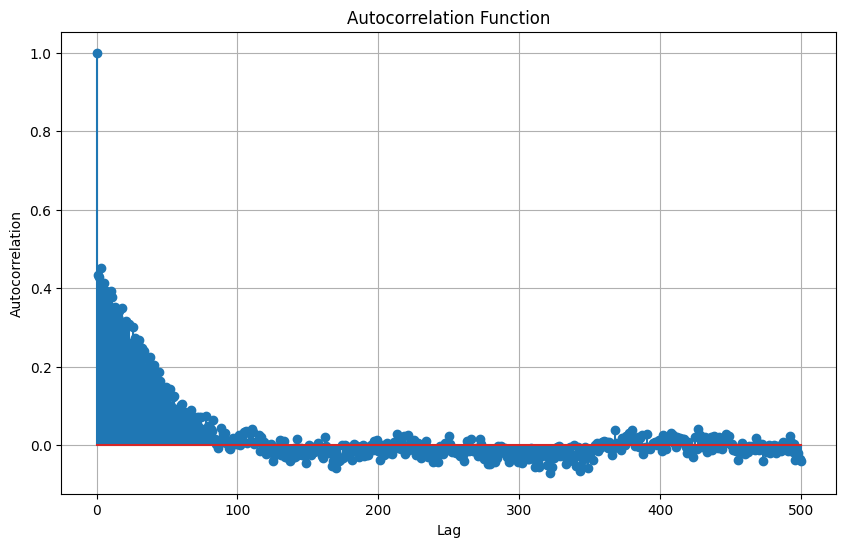

stats decorrelation time 33.96 gives smoothing window of 203 points.


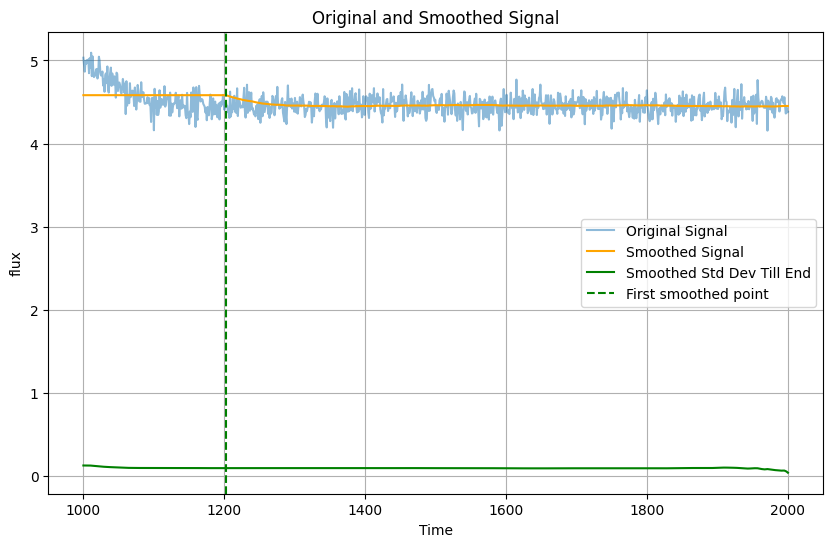

Getting start of SSS based on smoothed signal:
Index where criterion is met: 202
Rolling window: 203
time where criterion is met: 1203.00
time at start of SSS (adjusted for rolling window): 1101.00


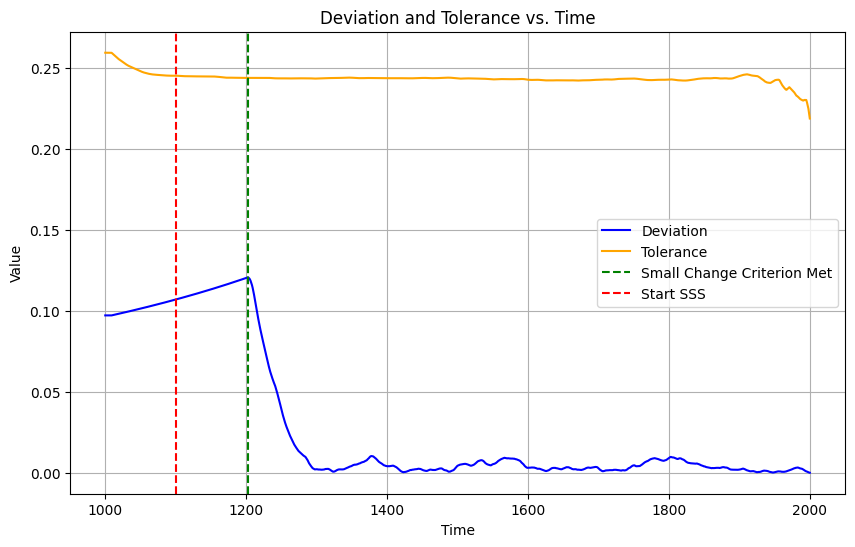

Data saved to /Users/bjdebus/Research/FESFrontiers/Repos/quends/tests/start_time_demo/output/flat_signal_stats_with_time_of_restart.csv


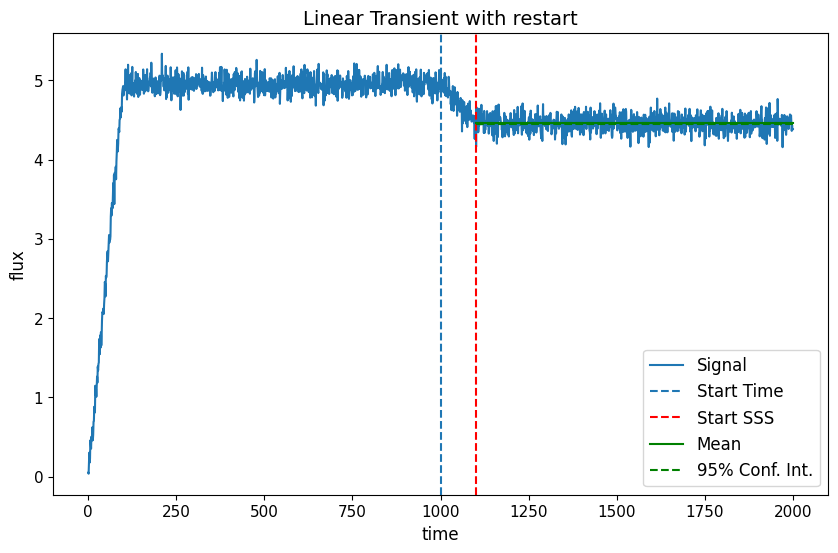

In [4]:
# get statistics with start_time provided
my_stats = my_wrkflw.process_data_steam(ds_flat,col, start_time=1001.0)
df_stats = pd.DataFrame([my_stats])
save_stats_to_csv(df_stats, "flat_signal_stats_with_time_of_restart.csv")

# Plot trace with mean and start of steady state
if not my_stats[col]["metadata"]["mitigation"] == "Drop":
    my_wrkflw.plot_signal_basic_stats(ds_flat,col,stats=my_stats,label=my_label)


By providing the start_time, quends has an easier time finding the start of SSS. In this particular case, we are calling the start of SSS a bit too early. This could be avoided by using a tighter tolerance on the change in smoothed mean. Either way, the estimated mean would be pretty accurate even without adjusting the hyperparameters.

### Create a noisier variant to exercise the same workflow


Original size of data stream: 2001 points.
After enforcing start time there are 2001 points left.


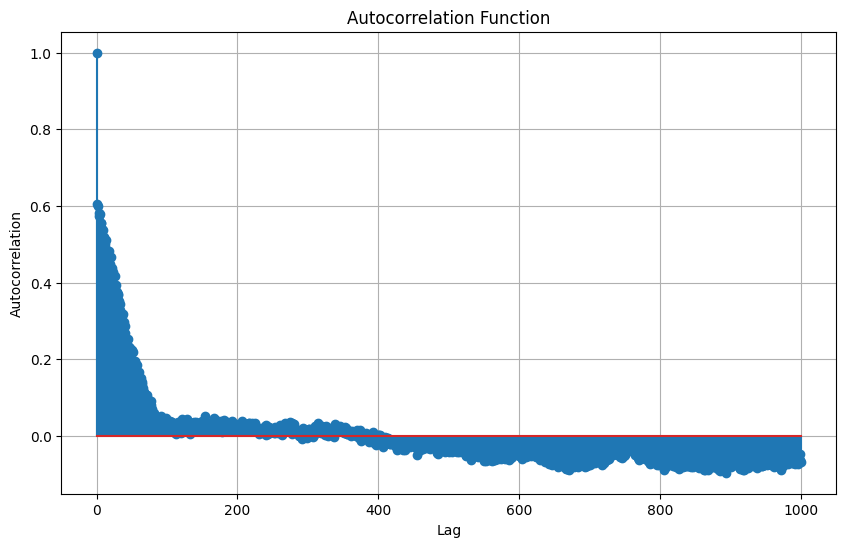

stats decorrelation time 58.90 gives smoothing window of 353 points.


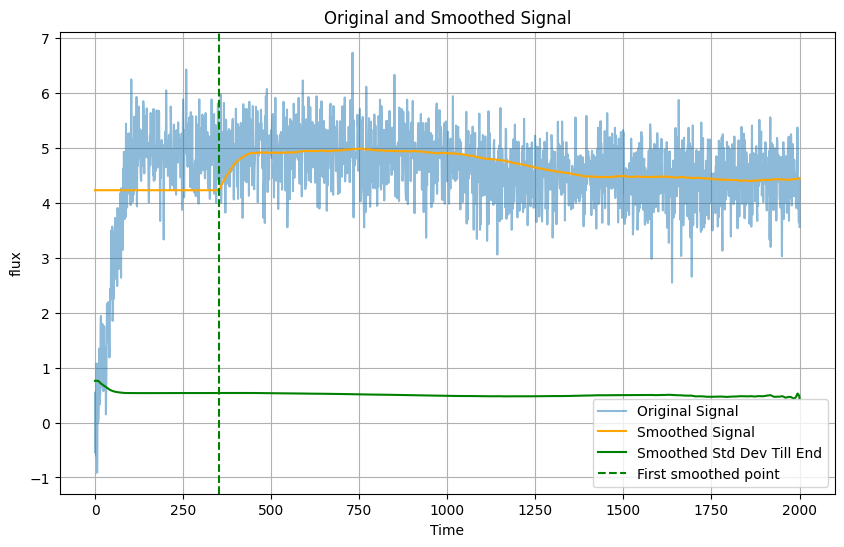

Getting start of SSS based on smoothed signal:
Index where criterion is met: 352
Rolling window: 353
time where criterion is met: 352.00
time at start of SSS (adjusted for rolling window): 175.00


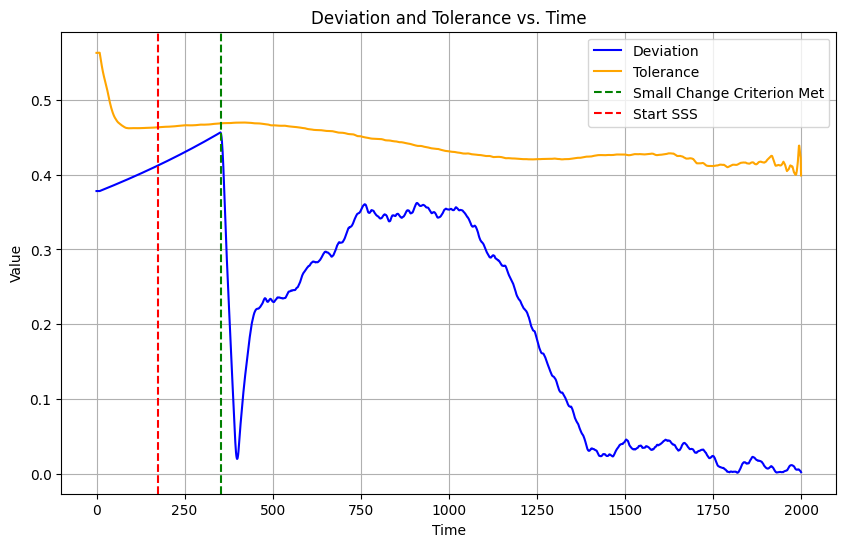

Data saved to /Users/bjdebus/Research/FESFrontiers/Repos/quends/tests/start_time_demo/output/flat_signal_stats_with_noise.csv


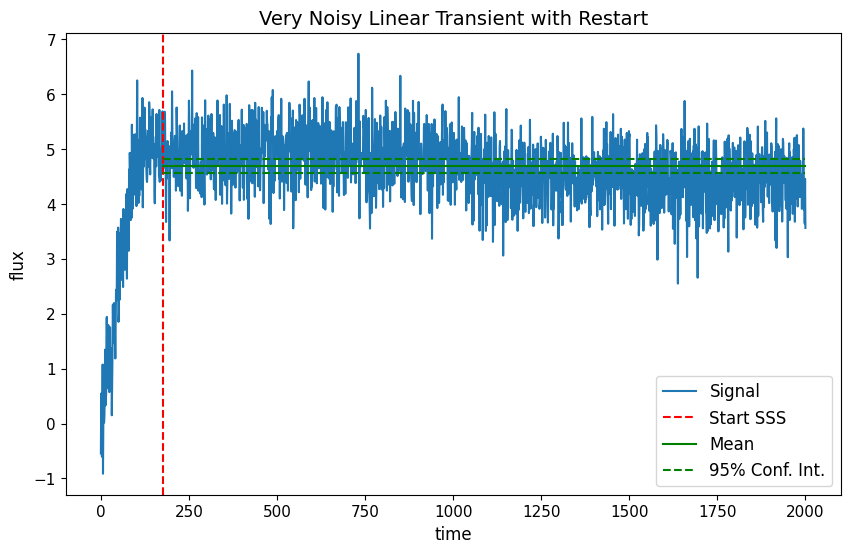

In [ ]:

my_label = "Very Noisy Linear Transient with Restart"
np.random.seed(123)
arr_time_noise = np.linspace(start=0, stop=2000, num=2001)
arr_signal_noise = np.zeros_like(arr_time_noise)
for i_arr in range(100):
    arr_signal_noise[i_arr] = 0.05 * arr_time_noise[i_arr]
for i_arr in range(100, 1000):
    arr_signal_noise[i_arr] = arr_signal_noise[99]
for i_arr in range(1000, 1100):
    arr_signal_noise[i_arr] = arr_signal_noise[999] - 0.005 * (arr_time_noise[i_arr] - arr_time_noise[999])
for i_arr in range(1100, len(arr_time_noise)):
    arr_signal_noise[i_arr] = arr_signal_noise[1099]
arr_signal_noise += np.random.normal(loc=0.0, scale=0.5, size=arr_signal_noise.shape)

df_noise = pd.DataFrame({"time": arr_time_noise, "flux": arr_signal_noise})
ds_noise = qnds.DataStream(df_noise)

noise_wrkflw = qnds.RobustWorkflow(operate_safe=False, verbosity=2)
noise_stats = noise_wrkflw.process_data_steam(ds_noise, "flux")
df_noise_stats = pd.DataFrame([noise_stats])
save_stats_to_csv(df_noise_stats, "flat_signal_stats_with_noise.csv")

if not noise_stats[col]["metadata"]["mitigation"] == "Drop":
    noise_wrkflw.plot_signal_basic_stats(ds_noise,col,stats=noise_stats,label=my_label)


It is hard to see with the noise, but we are calling the start of SSS too soon, and totally miss the restart point.

next, we do this again, but specify the restart time

Original size of data stream: 2001 points.
After enforcing start time there are 1000 points left.


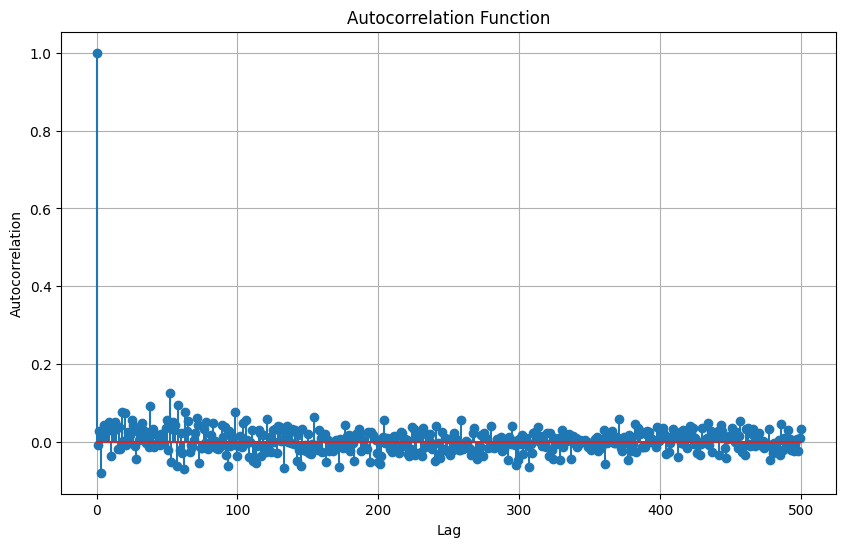

stats decorrelation time 1.04 gives smoothing window of 6 points.


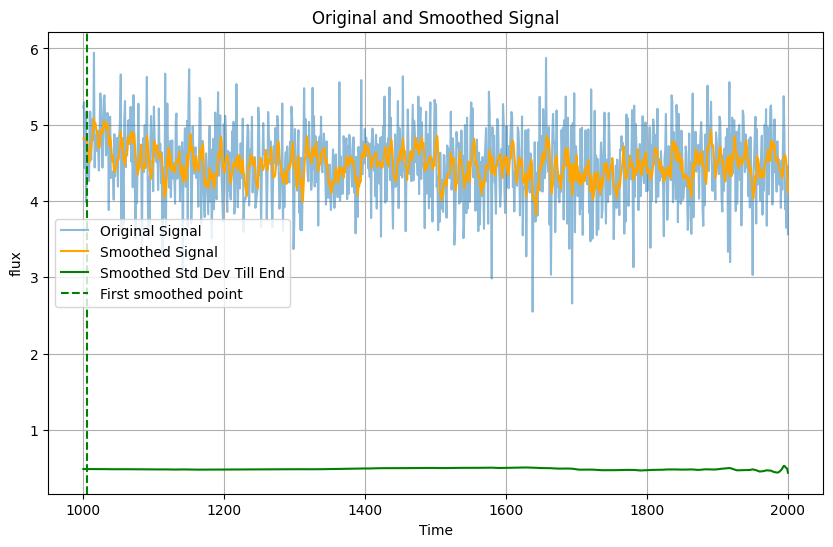

Getting start of SSS based on smoothed signal:
Index where criterion is met: 40
Rolling window: 6
time where criterion is met: 1041.00
time at start of SSS (adjusted for rolling window): 1038.00


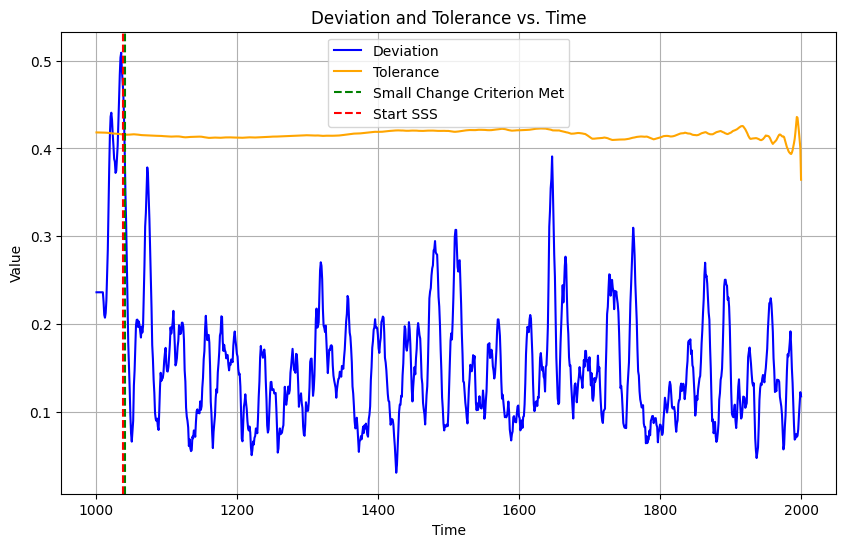

Data saved to /Users/bjdebus/Research/FESFrontiers/Repos/quends/tests/start_time_demo/output/flat_signal_stats_with_noise_and_restart_provided.csv


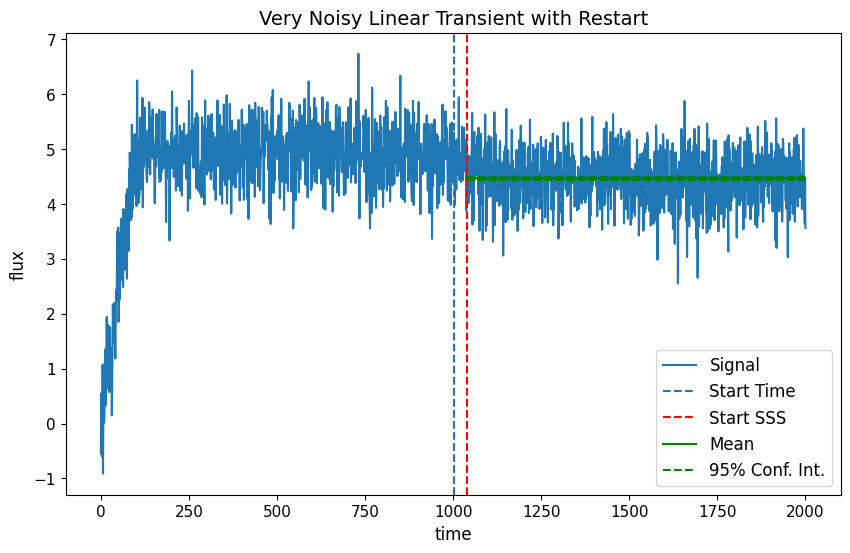

In [10]:
# get statistics with start_time provided

noise_stats = noise_wrkflw.process_data_steam(ds_noise, "flux", start_time=1001.0)
df_noise_stats = pd.DataFrame([noise_stats])
save_stats_to_csv(df_noise_stats, "flat_signal_stats_with_noise_and_restart_provided.csv")

if not noise_stats[col]["metadata"]["mitigation"] == "Drop":
    noise_wrkflw.plot_signal_basic_stats(ds_noise,col,stats=noise_stats,label=my_label)